In [76]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import random
import statsmodels.api as sm
import statsmodels.stats.diagnostic as smd
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
import scipy.stats as stats
import statsmodels.stats.diagnostic as diag
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.compose import make_column_selector as selector
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import root_mean_squared_error
from sklearn.impute import SimpleImputer



train_data = pd.read_csv("csv/train.csv",  encoding='latin-1')
train_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


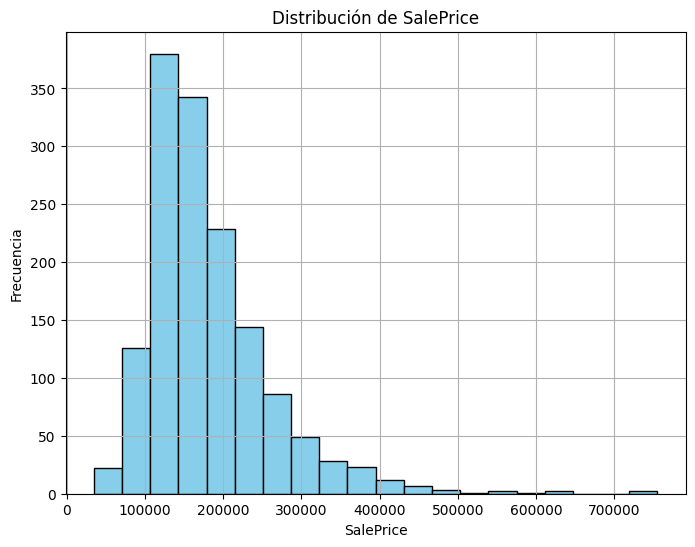

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [77]:
plt.figure(figsize=(8, 6))
plt.hist(train_data['SalePrice'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribución de SalePrice')
plt.xlabel('SalePrice')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()
print(train_data['SalePrice'].describe())

In [78]:
train_data.pop("LotFrontage")
train_data.pop("Id")
print(train_data.isnull().sum())

MSSubClass          0
MSZoning            0
LotArea             0
Street              0
Alley            1369
                 ... 
MoSold              0
YrSold              0
SaleType            0
SaleCondition       0
SalePrice           0
Length: 79, dtype: int64


In [79]:
print(train_data.dtypes)

MSSubClass        int64
MSZoning         object
LotArea           int64
Street           object
Alley            object
                  ...  
MoSold            int64
YrSold            int64
SaleType         object
SaleCondition    object
SalePrice         int64
Length: 79, dtype: object


In [80]:
y = train_data.pop("SalePrice")
X = train_data

In [81]:
y_mean= y.mean()
print(y, '\n')
print(X)
print(X.columns)

0       208500
1       181500
2       223500
3       140000
4       250000
         ...  
1455    175000
1456    210000
1457    266500
1458    142125
1459    147500
Name: SalePrice, Length: 1460, dtype: int64 

      MSSubClass MSZoning  LotArea Street Alley LotShape LandContour  \
0             60       RL     8450   Pave   NaN      Reg         Lvl   
1             20       RL     9600   Pave   NaN      Reg         Lvl   
2             60       RL    11250   Pave   NaN      IR1         Lvl   
3             70       RL     9550   Pave   NaN      IR1         Lvl   
4             60       RL    14260   Pave   NaN      IR1         Lvl   
...          ...      ...      ...    ...   ...      ...         ...   
1455          60       RL     7917   Pave   NaN      Reg         Lvl   
1456          20       RL    13175   Pave   NaN      Reg         Lvl   
1457          70       RL     9042   Pave   NaN      Reg         Lvl   
1458          20       RL     9717   Pave   NaN      Reg         Lvl 

In [82]:
X_train, X_test,y_train, y_test = train_test_split(X, y,test_size=0.3,train_size=0.7,random_state=0)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1021, 78)
(438, 78)
(1021,)
(438,)


# Modelo

In [83]:
numerical_columns_selector = selector(dtype_exclude=object)
categorical_columns_selector = selector(dtype_include=object)

numerical_columns = numerical_columns_selector(train_data)
categorical_columns = categorical_columns_selector(train_data)
print('Categoricas:\n', categorical_columns)
print('Numericas:\n',numerical_columns)

Categoricas:
 ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']
Numericas:
 ['MSSubClass', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchS

In [84]:
categorical_preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Imputar con el valor más frecuente
    ('encoder', OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

numerical_preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # Imputar con la mediana
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('one-hot-encoder', categorical_preprocessor, categorical_columns),
    ('standard-scaler', numerical_preprocessor, numerical_columns)
])

    

In [85]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', GaussianNB())
])
#params = [{
#    "regressor__max_depth": np.arange(2, 10, 1)
#}]
pipeline.get_params()

{'memory': None,
 'steps': [('preprocessor',
   ColumnTransformer(transformers=[('one-hot-encoder',
                                    Pipeline(steps=[('imputer',
                                                     SimpleImputer(strategy='most_frequent')),
                                                    ('encoder',
                                                     OneHotEncoder(handle_unknown='ignore',
                                                                   sparse_output=False))]),
                                    ['MSZoning', 'Street', 'Alley', 'LotShape',
                                     'LandContour', 'Utilities', 'LotConfig',
                                     'LandSlope', 'Neighborhood', 'Condition1',
                                     'Condition2', 'BldgType', 'HouseStyle',
                                     'Ro...
                                     'OverallCond', 'YearBuilt', 'YearRemodAdd',
                                     'MasVnrArea', 'B

In [86]:
modelo = pipeline.fit(X_train, y_train)
y_pred = modelo.predict(X_test)
rmse = root_mean_squared_error(y_test,y_pred)
rmse

68292.01121473452

## El error es de 68,292 dolares por casa aproximadamente

In [88]:
porcentaje = rmse / y_mean * 100
porcentaje

np.float64(37.74682721868637)

## El porcentaje de error con la media de SalePrice (180,921 dolares) es de 37.75%, lo cual es alto